### Imports and Environment Setup


In [35]:
# CELL 1: Environment Setup & Corrected Loader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings

plt.style.use('default')
sns.set_style("whitegrid")
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
warnings.filterwarnings('ignore')

DATA_DIR = '../data/raw/'

def load_and_clean_feature(feature_name, value_col_name):
    file_list = glob.glob(f"{DATA_DIR}*_{feature_name}.csv")
    df_list = []
    
    for file in file_list:
        country = os.path.basename(file).split('_')[0]
        try:
            df = pd.read_csv(file)
            if df.empty: continue
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
            df.set_index('Timestamp', inplace=True)
            df = df[~df.index.duplicated(keep='last')]
            
            if value_col_name in df.columns:
                df = df[[value_col_name]].rename(columns={value_col_name: country})
                df_list.append(df)
        except: pass
            
    macro_df = pd.concat(df_list, axis=1)
    # 🛑 THE FIX: Strictly slice the data to Q1 to remove stray future forecasts
    return macro_df.loc['2026-01-01':'2026-03-31']

# Load the core Load datasets
eu_actual_load = load_and_clean_feature('Actual_Load', 'Value_MW')
eu_forecast_load = load_and_clean_feature('Forecast_Load', 'Value_MW')

print(f"Loaded EU Actual Load. Shape: {eu_actual_load.shape}")
print(f"Loaded EU Forecast Load. Shape: {eu_forecast_load.shape}")

Loaded EU Actual Load. Shape: (8640, 25)
Loaded EU Forecast Load. Shape: (8640, 25)


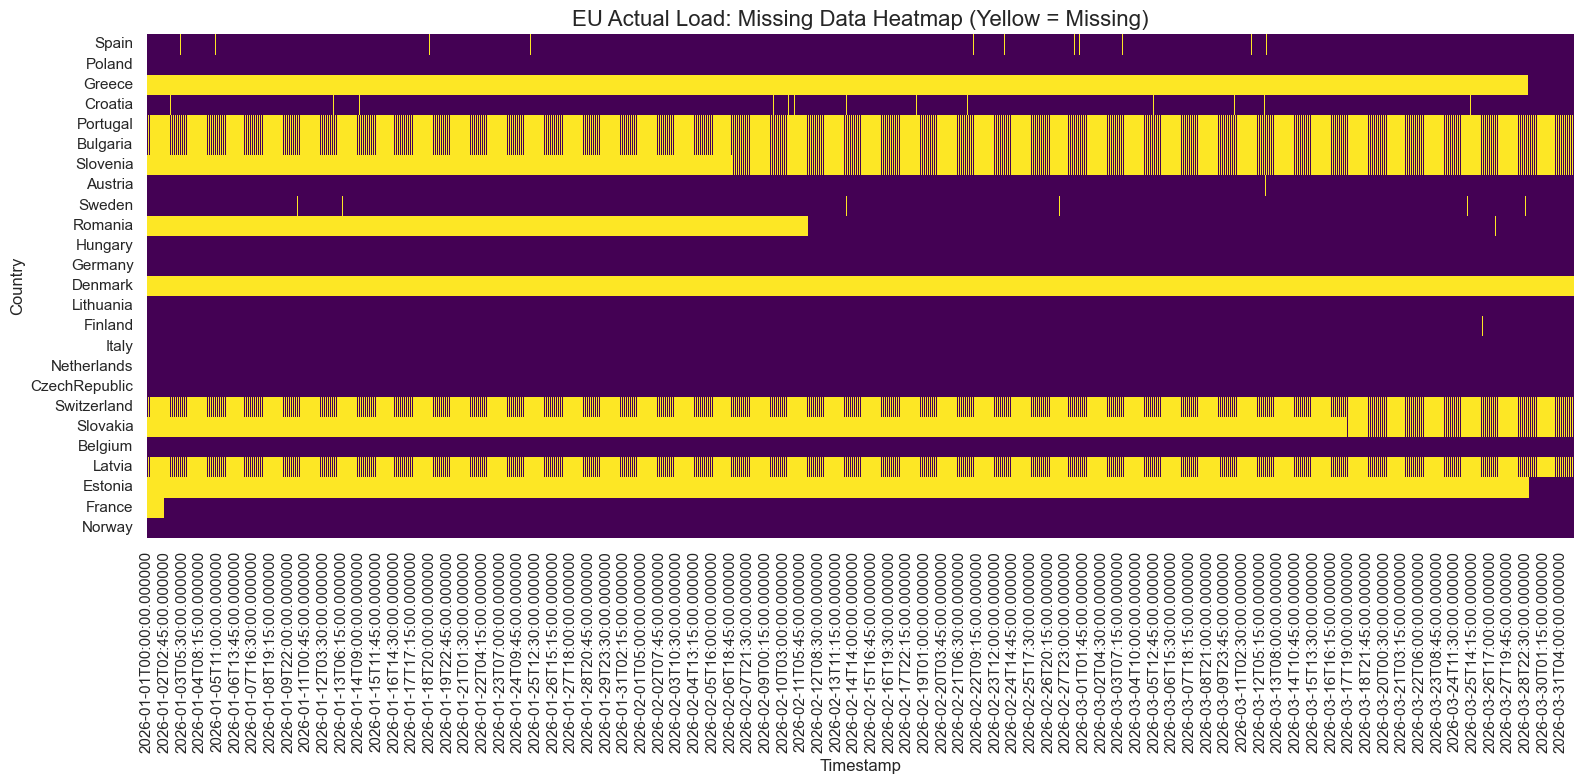

In [36]:
# CELL 2: Visualizing Missing Data
# Before doing math, we need to know exactly where the holes are.

plt.figure(figsize=(16, 8))
sns.heatmap(eu_actual_load.isnull().T, cbar=False, cmap='viridis')

plt.title("EU Actual Load: Missing Data Heatmap (Yellow = Missing)", fontsize=16)
plt.xlabel("Timestamp")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [37]:
# CELL 2.5: The Great Filter (Dropping Unreliable Grids)

# Calculate the percentage of missing data for each country
missing_pct = eu_actual_load.isnull().mean() * 100

# Set a strict threshold (e.g., keep only if missing LESS than 5% of data)
strict_threshold = 5.0
golden_countries = missing_pct[missing_pct < strict_threshold].index.tolist()

bad_countries = missing_pct[missing_pct >= strict_threshold].index.tolist()

print(f"🗑️ Dropping {len(bad_countries)} unreliable countries: {bad_countries}")
print(f"🏆 Keeping {len(golden_countries)} Golden Countries: {golden_countries}")

# Filter our main datasets to only include the reliable countries
eu_actual_load = eu_actual_load[golden_countries]

# Ensure we only keep forecast columns for countries that survived the cut
forecast_cols = [c for c in golden_countries if c in eu_forecast_load.columns]
eu_forecast_load = eu_forecast_load[forecast_cols]

print(f"\n✅ Data Warehouse cleaned. New EU Load Shape: {eu_actual_load.shape}")

🗑️ Dropping 10 unreliable countries: ['Greece', 'Portugal', 'Bulgaria', 'Slovenia', 'Romania', 'Denmark', 'Switzerland', 'Slovakia', 'Latvia', 'Estonia']
🏆 Keeping 15 Golden Countries: ['Spain', 'Poland', 'Croatia', 'Austria', 'Sweden', 'Hungary', 'Germany', 'Lithuania', 'Finland', 'Italy', 'Netherlands', 'CzechRepublic', 'Belgium', 'France', 'Norway']

✅ Data Warehouse cleaned. New EU Load Shape: (8640, 15)


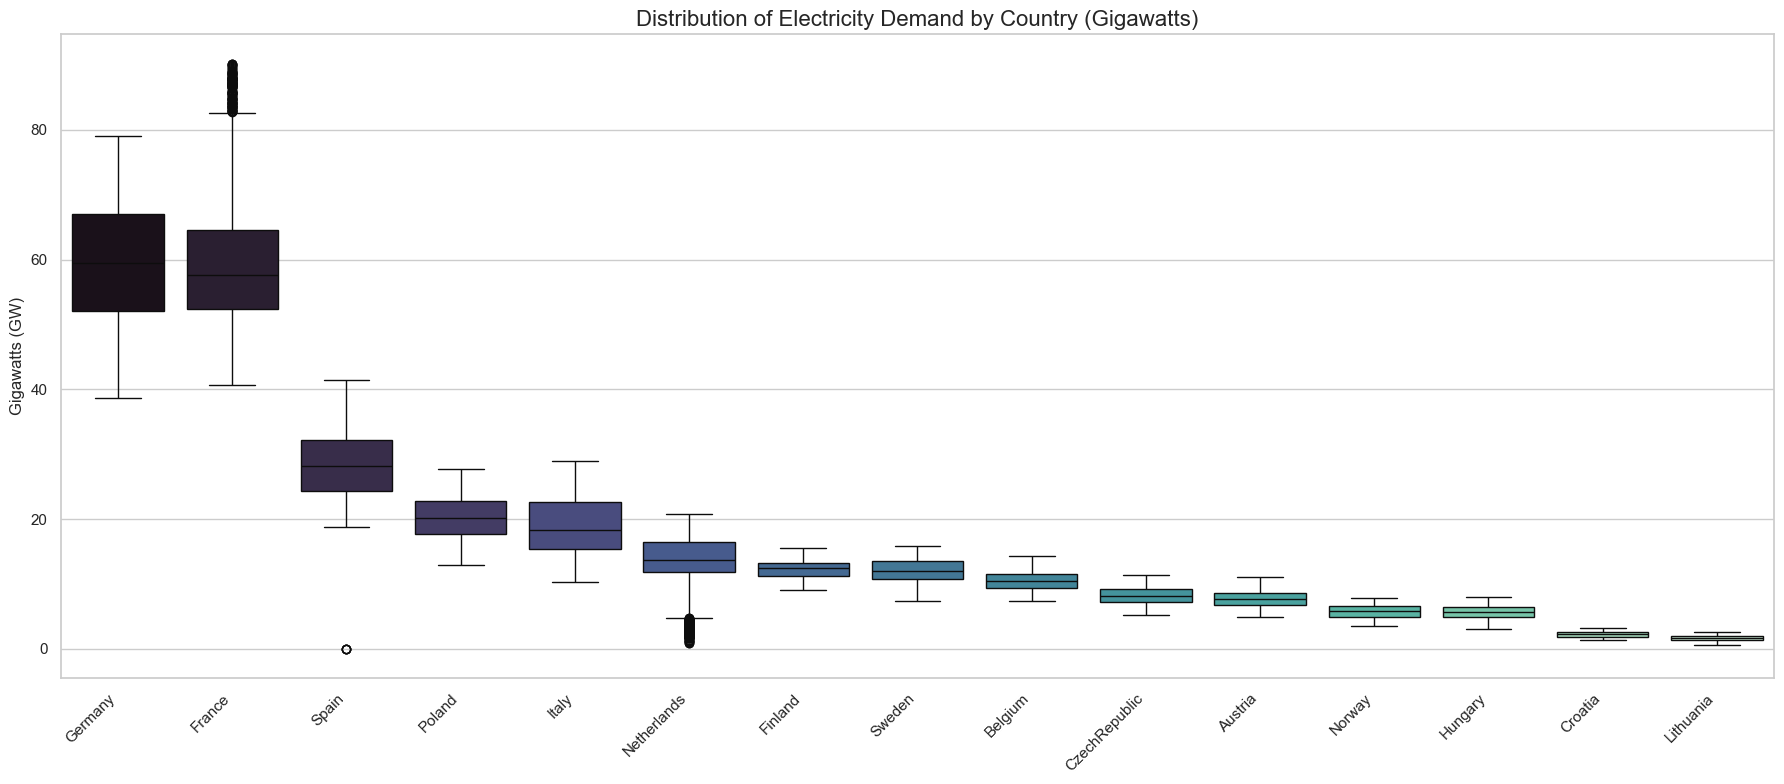

In [38]:
# CELL 4: Comparing the Size of European Grids
# This shows us the sheer scale difference between countries like Germany and smaller nations.

plt.figure(figsize=(18, 8))

# Sort by median load to make the chart readable
sorted_countries = eu_actual_load.median().sort_values(ascending=False).index
sns.boxplot(data=eu_actual_load[sorted_countries] / 1000, palette='mako')

plt.title("Distribution of Electricity Demand by Country (Gigawatts)", fontsize=16)
plt.ylabel("Gigawatts (GW)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

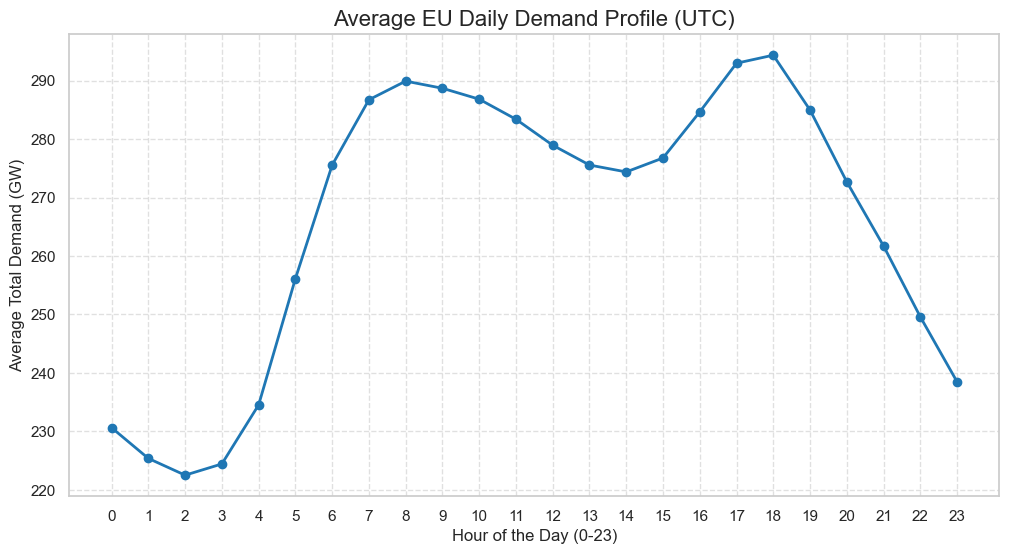

In [39]:
# CELL 5: Average Hourly Demand Profile
# When does Europe wake up, and when do they go to sleep?

eu_actual_load['Hour'] = eu_actual_load.index.hour
hourly_profile = eu_actual_load.groupby('Hour').mean().sum(axis=1) / 1000 # Total GW

plt.figure(figsize=(12, 6))
plt.plot(hourly_profile.index, hourly_profile, marker='o', color='#1f77b4', linewidth=2)

plt.title("Average EU Daily Demand Profile (UTC)", fontsize=16)
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Total Demand (GW)")
plt.xticks(np.arange(0, 24, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Clean up the Hour column for future cells
eu_actual_load.drop(columns=['Hour'], inplace=True)

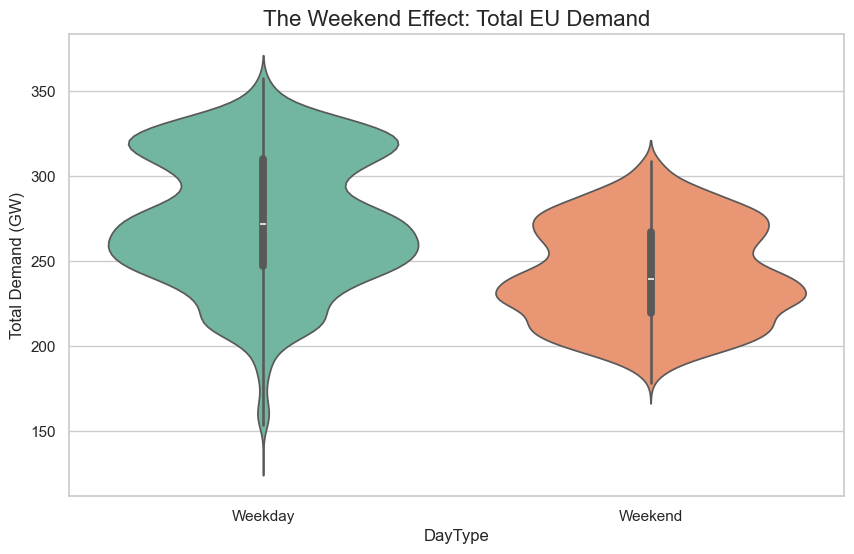

In [40]:
# CELL 6: Weekday vs Weekend Consumption
# Industrial demand drops on weekends. Let's quantify it.

eu_total_df = pd.DataFrame({'Total_Load_GW': eu_actual_load.sum(axis=1) / 1000})
eu_total_df['DayType'] = np.where(eu_total_df.index.dayofweek < 5, 'Weekday', 'Weekend')

plt.figure(figsize=(10, 6))
sns.violinplot(data=eu_total_df, x='DayType', y='Total_Load_GW', palette='Set2')

plt.title("The Weekend Effect: Total EU Demand", fontsize=16)
plt.ylabel("Total Demand (GW)")
plt.show()

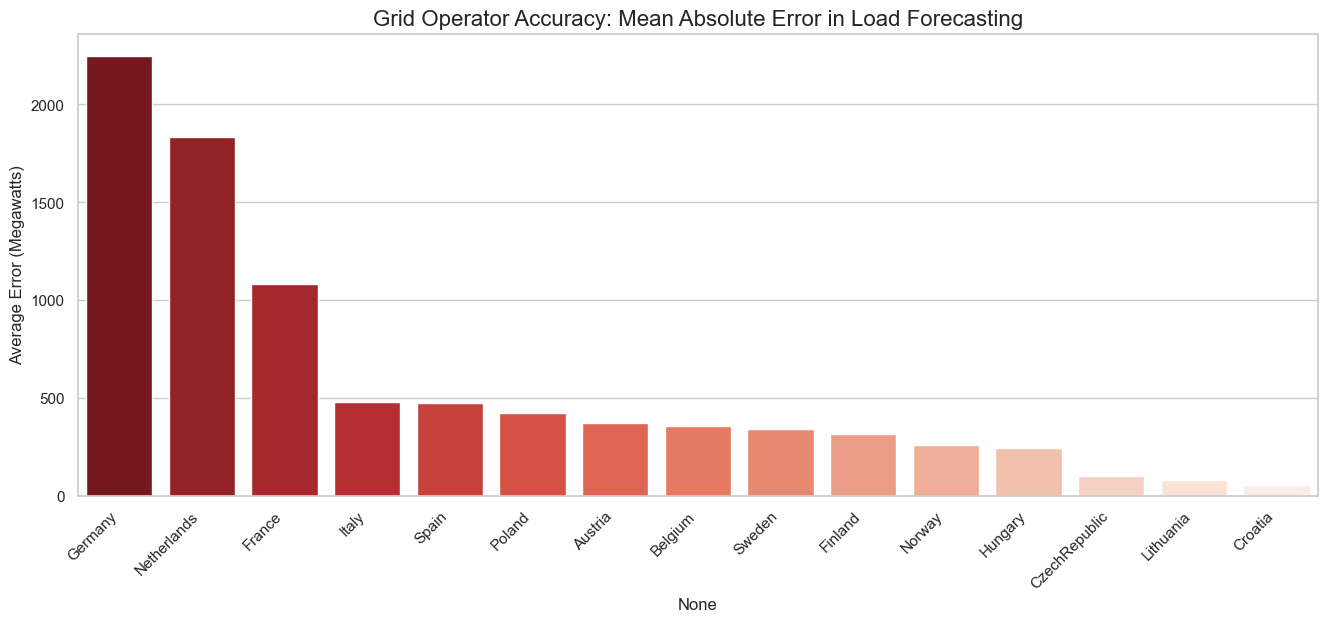

In [41]:
# CELL 7: Mean Absolute Error of Grid Operators
# How badly do country operators guess their own demand?

# Align the dataframes
actual, forecast = eu_actual_load.align(eu_forecast_load, join='inner')

# Calculate Absolute Error in MW
absolute_error = (actual - forecast).abs()
mean_error = absolute_error.mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(x=mean_error.index, y=mean_error.values, palette='Reds_r')

plt.title("Grid Operator Accuracy: Mean Absolute Error in Load Forecasting", fontsize=16)
plt.ylabel("Average Error (Megawatts)")
plt.xticks(rotation=45, ha='right')
plt.show()

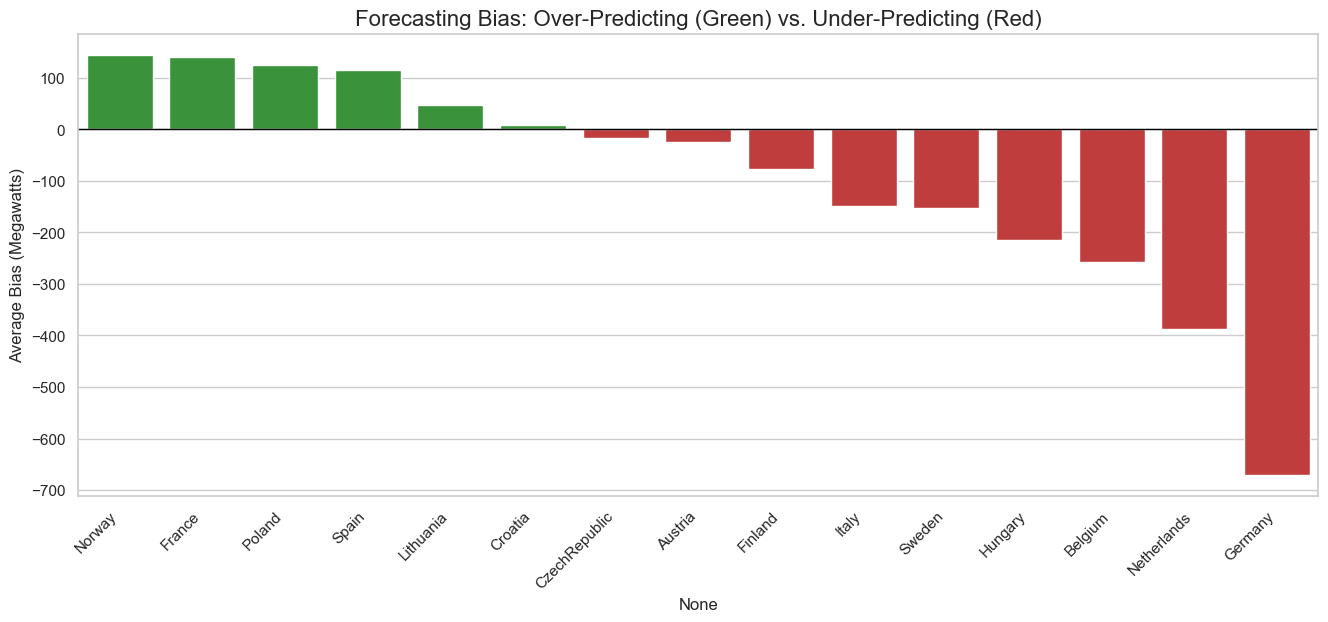

In [42]:
# CELL 8: Directional Bias
# Are operators more likely to over-forecast (safe) or under-forecast (dangerous)?

bias = (forecast - actual).mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
colors = ['#d62728' if val < 0 else '#2ca02c' for val in bias.values]
sns.barplot(x=bias.index, y=bias.values, palette=colors)

plt.axhline(0, color='black', linewidth=1)
plt.title("Forecasting Bias: Over-Predicting (Green) vs. Under-Predicting (Red)", fontsize=16)
plt.ylabel("Average Bias (Megawatts)")
plt.xticks(rotation=45, ha='right')
plt.show()

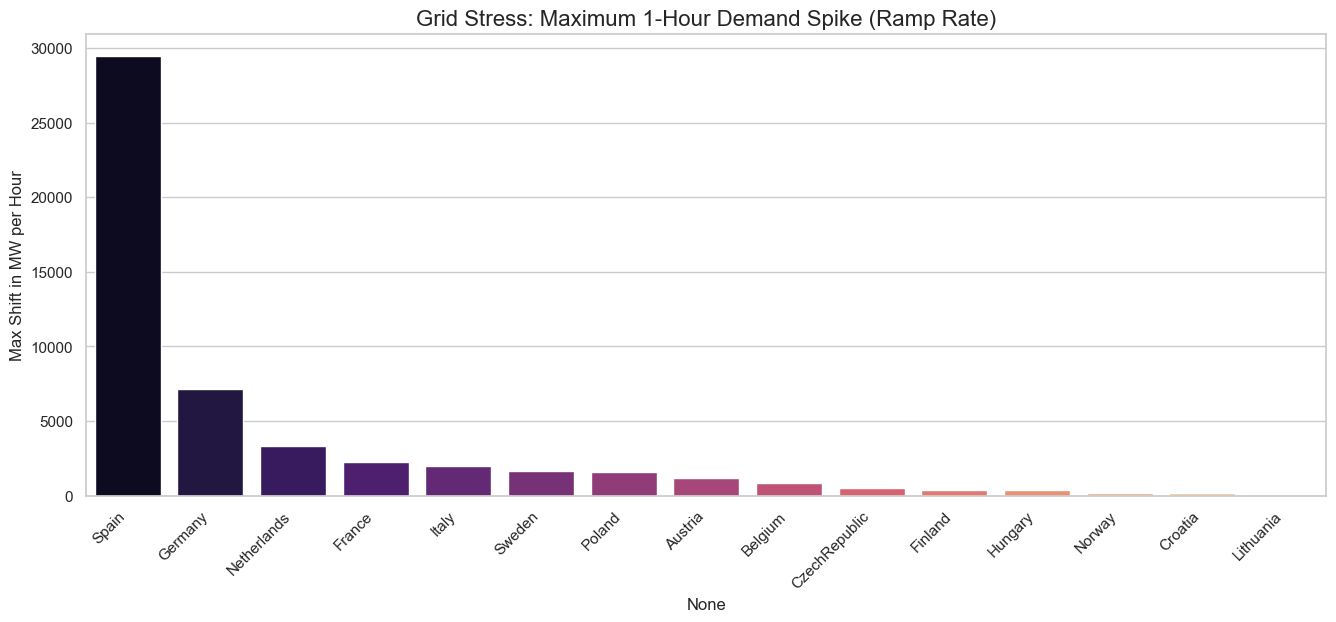

In [43]:
# CELL 9: Maximum Hourly Ramp Rates
# The grid breaks when demand spikes too fast. Who deals with the hardest spikes?

# Calculate the hour-to-hour change in demand (derivative)
ramp_rates = eu_actual_load.diff().abs()
max_ramps = ramp_rates.max().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(x=max_ramps.index, y=max_ramps.values, palette='magma')

plt.title("Grid Stress: Maximum 1-Hour Demand Spike (Ramp Rate)", fontsize=16)
plt.ylabel("Max Shift in MW per Hour")
plt.xticks(rotation=45, ha='right')
plt.show()

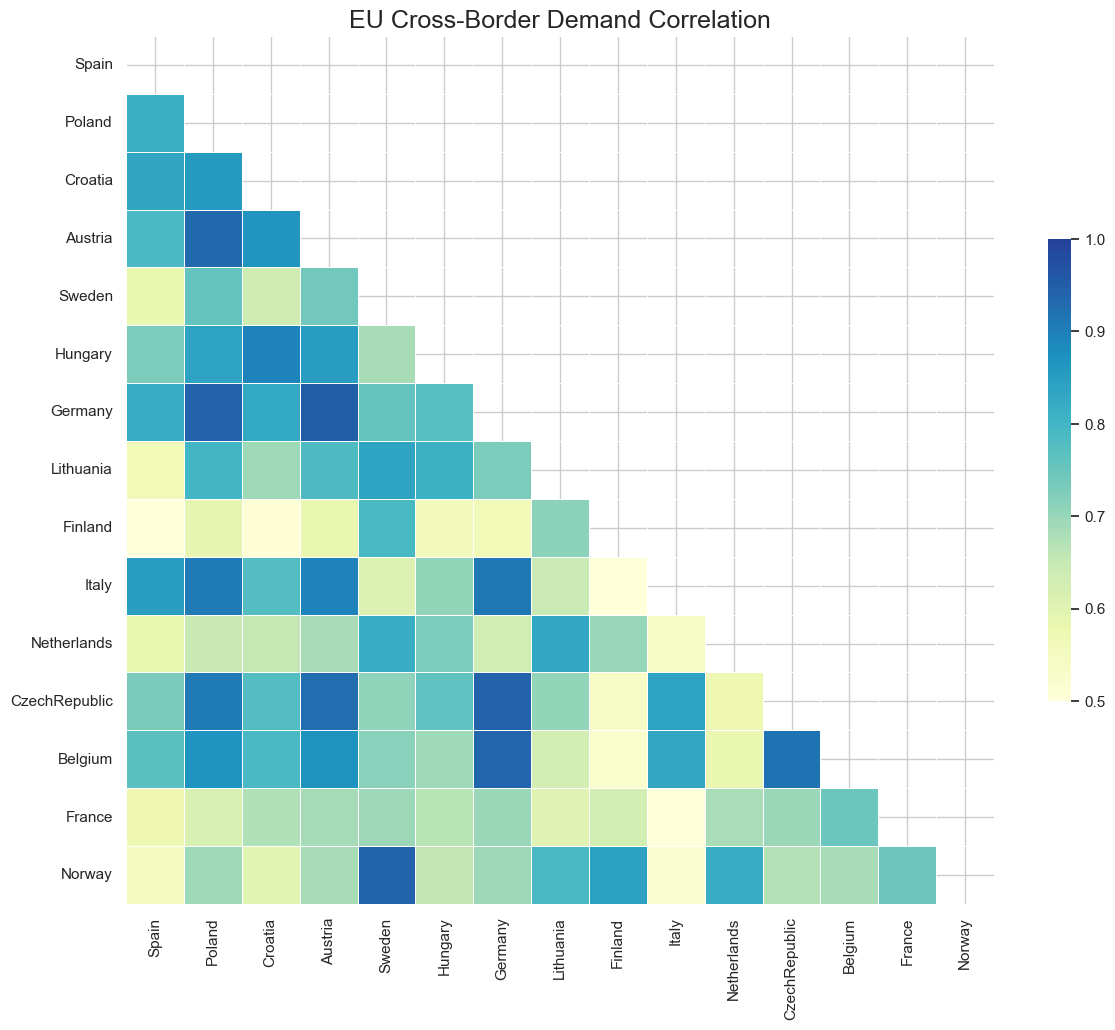

In [44]:
# CELL 10: Demand Synchronization Network
# Do countries turn their lights on at the exact same time?

plt.figure(figsize=(14, 12))

# Calculate Pearson correlation for load
load_corr = eu_actual_load.corr()
mask = np.triu(np.ones_like(load_corr, dtype=bool))

sns.heatmap(load_corr, mask=mask, cmap='YlGnBu', vmin=0.5, vmax=1, center=0.8, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title("EU Cross-Border Demand Correlation", fontsize=18)
plt.show()

### The European Price Convergence

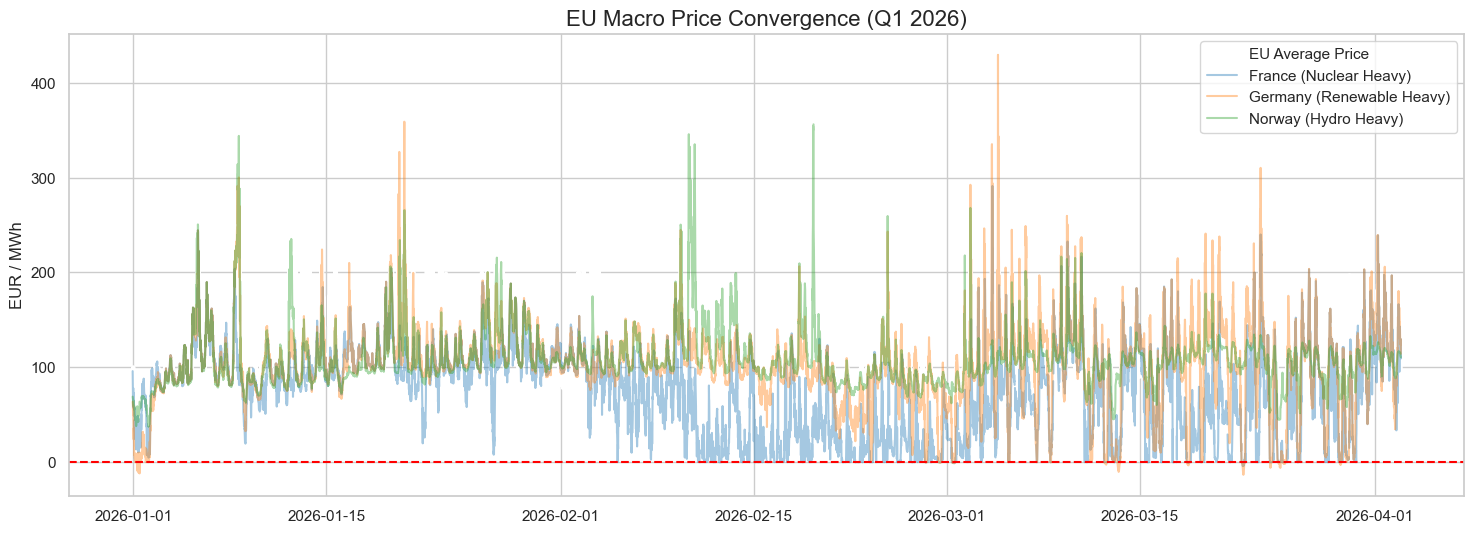

In [45]:
# Visualizing the Continental Price Trend
# Are EU countries moving together, or are they isolated?

plt.figure(figsize=(18, 6))

# Plot the EU Average
eu_avg_price = eu_prices.mean(axis=1)
plt.plot(eu_avg_price.index, eu_avg_price, color='white', linewidth=3, label='EU Average Price')

# Overlay a few major distinct zones for context
if 'France' in eu_prices.columns:
    plt.plot(eu_prices.index, eu_prices['France'], alpha=0.4, label='France (Nuclear Heavy)')
if 'Germany' in eu_prices.columns:
    plt.plot(eu_prices.index, eu_prices['Germany'], alpha=0.4, label='Germany (Renewable Heavy)')
if 'Norway' in eu_prices.columns:
    plt.plot(eu_prices.index, eu_prices['Norway'], alpha=0.4, label='Norway (Hydro Heavy)')

plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title("EU Macro Price Convergence (Q1 2026)", fontsize=16)
plt.ylabel("EUR / MWh")
plt.legend()
plt.show()

### The Volatility Index (Boxplots)

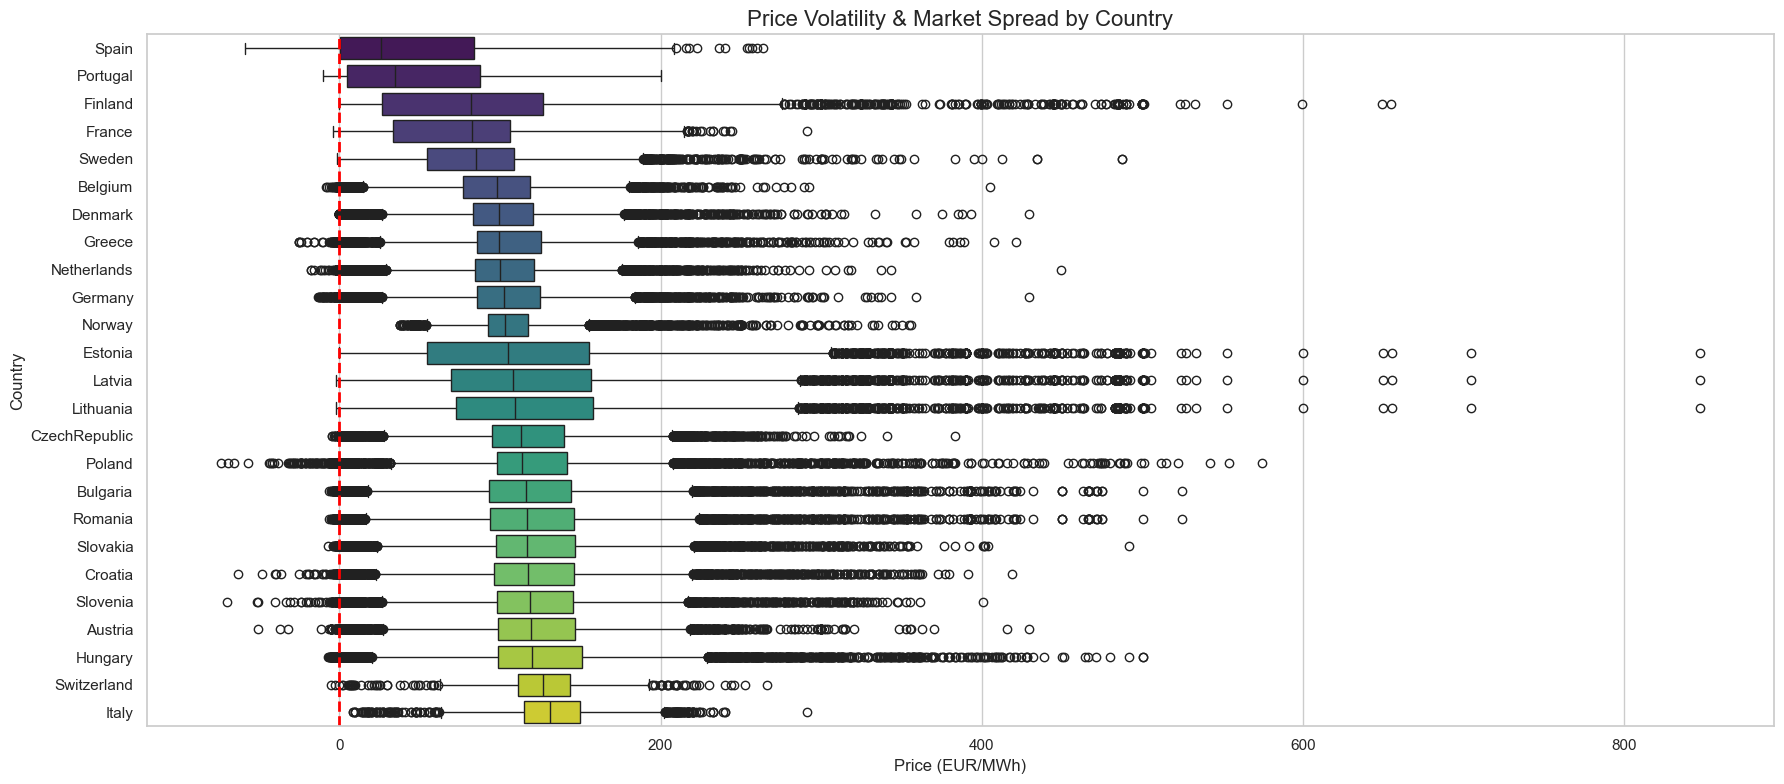

In [46]:
# Which countries have the most chaotic markets?
# Boxplots easily reveal outliers and extreme negative prices.

plt.figure(figsize=(18, 8))

# Sort countries by their median price
sorted_cols = eu_prices.median().sort_values().index
sns.boxplot(data=eu_prices[sorted_cols], palette='viridis', orient='h')

plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title("Price Volatility & Market Spread by Country", fontsize=16)
plt.xlabel("Price (EUR/MWh)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### The Negative Price Leaderboard

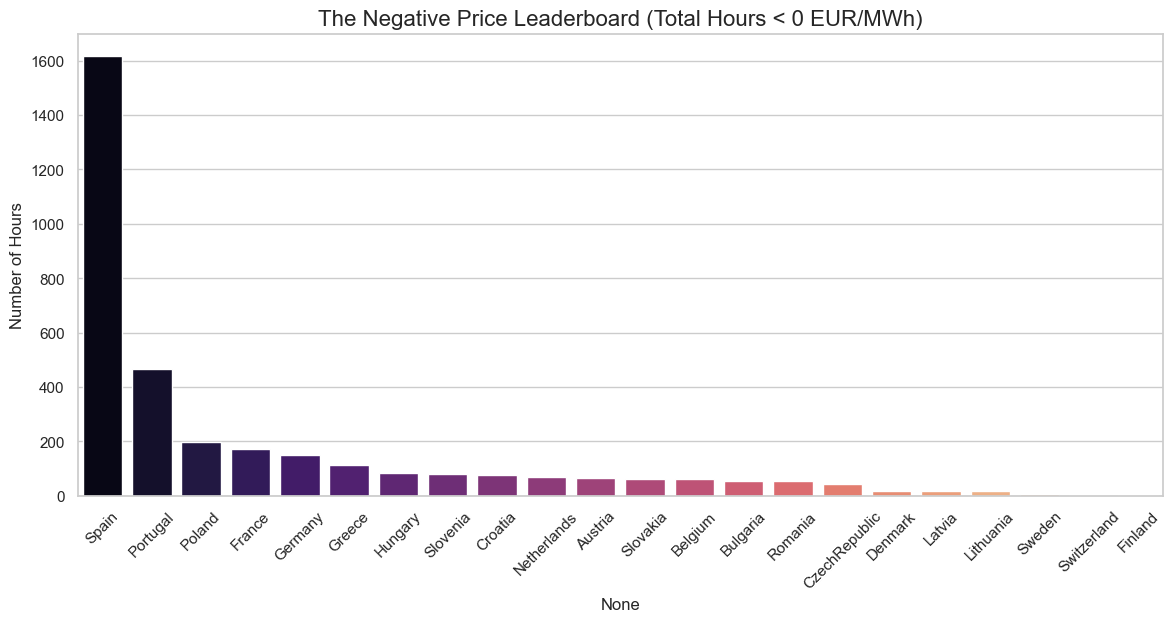

In [47]:
# CELL 5: Counting the Zero-Boundary Violations
# Which countries are over-producing so much they have to pay people to take electricity?

negative_counts = (eu_prices < 0).sum().sort_values(ascending=False)
negative_counts = negative_counts[negative_counts > 0] # Only keep countries with >0 negative hours

plt.figure(figsize=(14, 6))
sns.barplot(x=negative_counts.index, y=negative_counts.values, palette='magma')

plt.title("The Negative Price Leaderboard (Total Hours < 0 EUR/MWh)", fontsize=16)
plt.ylabel("Number of Hours")
plt.xticks(rotation=45)
plt.show()

### Total Continental Demand (The Macro Load)

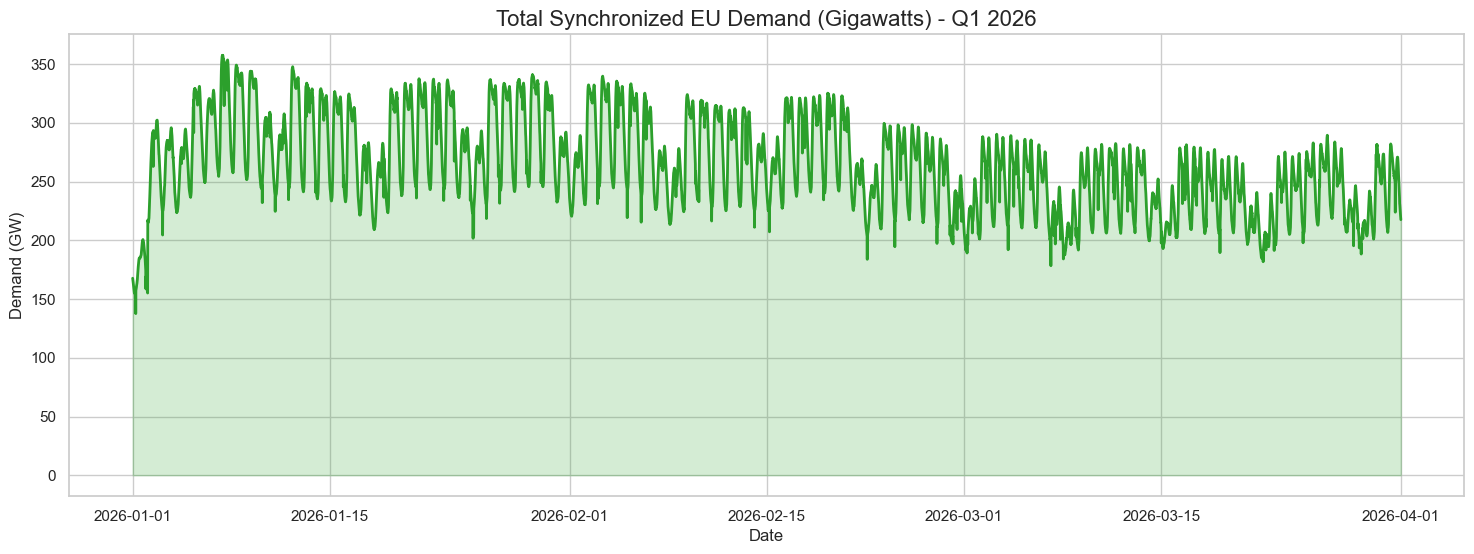

In [49]:
# CELL 3: Total Synchronized European Demand (Cleaned)
# Notice how the "cliff" is completely gone now.

eu_total_actual = eu_actual_load.sum(axis=1) / 1000 # GW

plt.figure(figsize=(18, 6))
plt.plot(eu_total_actual.index, eu_total_actual, color='#2ca02c', linewidth=2)
plt.fill_between(eu_total_actual.index, eu_total_actual, color='#2ca02c', alpha=0.2)

plt.title("Total Synchronized EU Demand (Gigawatts) - Q1 2026", fontsize=16)
plt.ylabel("Demand (GW)")
plt.xlabel("Date")
plt.show()

### Aggregating The EU Generation Mix

In [50]:
# CELL 8: What fuels the continent?
# We need to loop through every Actual_Generation file, extract the FuelType, and sum it globally.

print("Aggregating Continental Fuel Mix...")
file_list = glob.glob(f"{DATA_DIR}*_Actual_Generation.csv")

eu_gen_list = []
for file in file_list:
    try:
        df = pd.read_csv(file)
        if not df.empty:
            eu_gen_list.append(df)
    except: pass

eu_gen_master = pd.concat(eu_gen_list)
eu_gen_master['Timestamp'] = pd.to_datetime(eu_gen_master['Timestamp'])

# Group by Timestamp and FuelType across ALL countries
eu_fuel_mix = eu_gen_master.groupby(['Timestamp', 'FuelType'])['Gen_MW'].sum().unstack().fillna(0)

# Sort columns by total generation size
top_eu_fuels = eu_fuel_mix.sum().sort_values(ascending=False).index
eu_fuel_mix = eu_fuel_mix[top_eu_fuels]

print(f"Successfully aggregated {len(top_eu_fuels)} distinct fuel types across the EU.")

Aggregating Continental Fuel Mix...
Successfully aggregated 1 distinct fuel types across the EU.


### The Macro Merit Order Effect

In [52]:
# CELL 10: Do EU-wide renewables crash the EU-wide price?
# We calculate total EU Wind + Solar, and plot it against the average EU Price.

renewables = [col for col in eu_fuel_mix.columns if 'wind' in col.lower() or 'solar' in col.lower()]
if renewables:
    eu_total_renewable_mw = eu_fuel_mix[renewables].sum(axis=1)
    
    # Align the timestamps between generation and average price
    macro_analysis = pd.DataFrame({
        'EU_Total_Renewable_GW': eu_total_renewable_mw / 1000,
        'EU_Avg_Price': eu_avg_price
    }).dropna()

    plt.figure(figsize=(12, 7))
    sns.regplot(
        data=macro_analysis, 
        x='EU_Total_Renewable_GW', 
        y='EU_Avg_Price', 
        scatter_kws={'alpha':0.3, 'color':'#ff00ff'},
        line_kws={'color':'white', 'linewidth':3}
    )
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title("The Macro Merit Order: Continental Renewables vs. Average Continental Price", fontsize=16)
    plt.xlabel("Total Synchronized EU Renewable Generation (GW)")
    plt.ylabel("Average EU Market Price (EUR/MWh)")
    plt.show()
else:
    print("Could not isolate Wind/Solar for the macro calculation.")

Could not isolate Wind/Solar for the macro calculation.
